In [23]:
%load_ext autoreload
%autoreload 2
import physquirrel as sq
import matplotlib.pyplot as plt
import random       
import numpy as np
import networkx as nx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
quarnets = [sq.SplitQuarnet(sq.Split({1,2},{3,4}))]
Q = sq.DenseQuarnetSet(quarnets)
split = sq.Split({1},{2,3,4})
split2 = sq.Split({1,2},{3,4})

In [25]:
score1 = split.get_splitscore(Q)
score2 = split2.get_splitscore(Q)
print(score1)
print(score2)

0
1.0


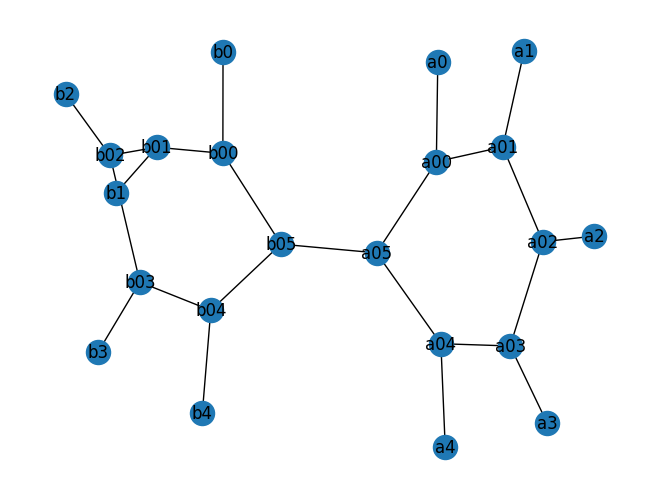

In [26]:
A = 5
B = 5

G = nx.Graph([(f'a0{i}', f'a0{i+1}') for i in range(A)]+[(f'a0{A}', f'a0{A-1}'), (f'a0{A}', 'a00')]+
             [(f'b0{i}', f'b0{i+1}') for i in range(B)]+[(f'b0{B}', f'b0{B-1}'), (f'b0{B}', 'b00')]+
             [(f'a0{A}', f'b0{B}')]+
             [(f'a{i}', f'a0{i}') for i in range(A)]+[(f'b{i}', f'b0{i}') for i in range(B)]
             )
nx.draw(G, with_labels=True)
plt.show()

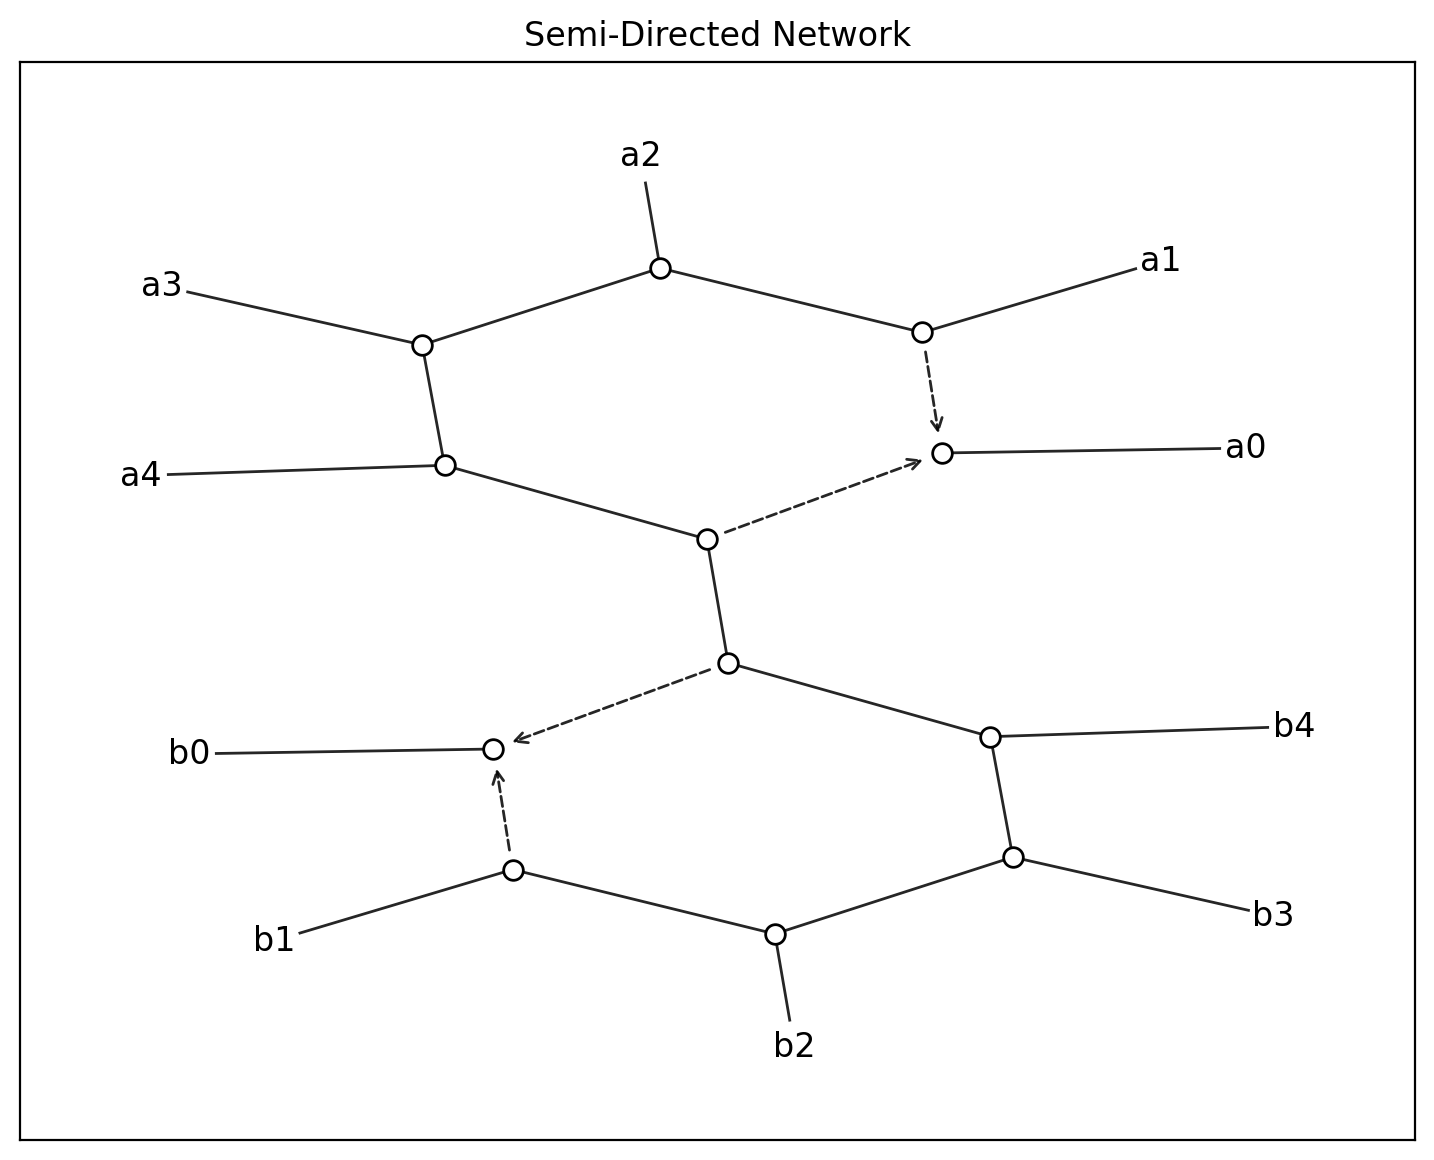

<Axes: title={'center': 'Semi-Directed Network'}>

In [28]:
directed_edges = {(f'a0{A}', 'a00'), ('a01', 'a00'), (f'b0{B}', 'b00'), ('b01', 'b00')}
leaves = {f'a{i}' for i in range(A)} | {f'b{i}' for i in range(B)}
N = sq.SemiDirectedNetwork.from_graph(G, directed_edges = directed_edges, leaves=leaves)
N.visualize()

In [32]:
L = N.splits(include_trivial=False)
print(L)

SplitSystem([
  Split({'b3', 'b0', 'b4', 'b2', 'b1'}, {'a0', 'a4', 'a2', 'a3', 'a1'})
])


In [34]:
Q, Q_splits = N.quarnets(triangles=False, return_4splits=True)

In [49]:
found_splits = []
for leaf in N.leaves:
    start_split = sq.Split({leaf}, set(N.leaves)-{leaf})
    found_split = Q.hill_climbing_single_split(start_split)
    if found_split not in found_splits:
        print(f"Found split: {found_split} with start split {start_split}")
        found_splits.append(found_split)


new_split = found_splits[1]
print(f"New split: {new_split}", new_split.get_splitscore(Q)) 
print(new_split.total_induced_weight, new_split.correct_splits_weight)   
new_split.set1.add('a0')
new_split.set2.remove('a0')
print(f"Modified split: {new_split}", new_split.get_splitscore(Q))
print(new_split.total_induced_weight, new_split.correct_splits_weight) 

Found split: Split({'b3', 'b0', 'b2', 'b4', 'b1'}, {'a0', 'a4', 'a2', 'a3', 'a1'}) with start split Split({'b3'}, {'a2', 'b4', 'b1', 'a3', 'a1', 'a0', 'a4', 'b0', 'b2'})
Found split: Split({'a2', 'a1'}, {'b3', 'b4', 'b1', 'a3', 'a0', 'a4', 'b0', 'b2'}) with start split Split({'a2'}, {'b3', 'b4', 'b1', 'a3', 'a1', 'a0', 'a4', 'b0', 'b2'})
Found split: Split({'b1', 'b2'}, {'b3', 'a2', 'b4', 'a3', 'a1', 'a0', 'a4', 'b0'}) with start split Split({'b1'}, {'b3', 'a2', 'b4', 'a3', 'a1', 'a0', 'a4', 'b0', 'b2'})
New split: Split({'a2', 'a1'}, {'b3', 'b4', 'b1', 'a3', 'a0', 'a4', 'b0', 'b2'}) 0.75
28.0 21.0
Modified split: Split({'a0', 'a2', 'a1'}, {'a4', 'b3', 'b0', 'b4', 'b2', 'b1', 'a3'}) 0.6507936507936508
63.0 41.0
